In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


In [3]:
df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


# Inspection of Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Conclusion : Need of Encoding 

In [5]:
df.shape

(2000, 8)

In [6]:
df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
(df['answer'].value_counts()/df.shape[0])*100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64

<Axes: xlabel='answer', ylabel='count'>

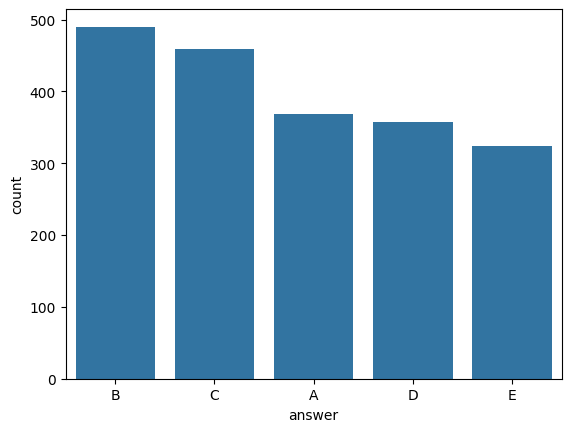

In [9]:
import seaborn as sns

sns.countplot(x=df['answer'], data=df, order=df['answer'].value_counts().index)

In [10]:
df['prompt_len'] = df['prompt'].str.split().str.len()


In [11]:
df['prompt_len'].unique

<bound method Series.unique of 0       22
1        5
2       27
3       19
4       15
        ..
1995    10
1996    16
1997    13
1998    37
1999    18
Name: prompt_len, Length: 2000, dtype: int64>

In [12]:
df['prompt_len'].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_len, dtype: float64

In [13]:
df=df.drop(['id'],axis=1)

# Train - Test split

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="answer")
y = df['answer']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
train_text=pd.concat(
    [
    X_train['prompt'],
    X_train['A'],
    X_train['B'],
    X_train['C'],
    X_train['D'],
    X_train['E']
    ]
).fillna('')

In [16]:
train_text.head(20)

386     Select the most accurate option: What is Modif...
1900    Determine the correct option: What is Lorentz ...
1697    Identify the correct statement: What is recipr...
714     Determine the correct option: Which of the fol...
1134    Select the most accurate option: What is the r...
866     Choose the correct answer: What is the informa...
252     Pick the best possible answer: What is the res...
1621    Choose the correct answer: What are the four q...
165     Pick the best possible answer: What is the def...
1180    Select the most accurate option: What is power...
539     Select the most accurate option: What is the P...
342     Pick the best possible answer: What is the mai...
420     Determine the correct option: Which mathematic...
1051    Pick the best possible answer: What is a plane...
1327    Pick the best possible answer: What is the pro...
214     Which of the following statements accurately d...
597                             What is the Ozma Problem?
1549    Choose

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer= TfidfVectorizer( ngram_range=(1,3), lowercase=True,
    max_features=80000,
    min_df=2)
vectorizer.fit(train_text)


TfidfVectorizer(max_features=80000, min_df=2, ngram_range=(1, 3))

In [18]:
print(len(vectorizer.vocabulary_))

25272


In [19]:
print(vectorizer.get_feature_names_out())

['000' '000 carefully' '000 from' ... 'φ0 2e where' 'φ0 2h' 'φ0 2h where']


In [20]:
def transform_columns(df, vectorizer):
    return (
        vectorizer.transform(df['prompt']),
        vectorizer.transform(df['A']),
        vectorizer.transform(df['B']),
        vectorizer.transform(df['C']),
        vectorizer.transform(df['D']),
        vectorizer.transform(df['E'])
    )

    
    

In [21]:
prompt_vec, A_vec, B_vec, C_vec, D_vec, E_vec = transform_columns(X_train, vectorizer)

prompt_val, A_val, B_val, C_val, D_val, E_val = transform_columns(X_val, vectorizer)

prompt_test, A_tt, B_tt, C_tt, D_tt, E_tt = transform_columns(test_df, vectorizer)

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

scores = {
    'A': cosine_similarity(prompt_vec, A_vec).diagonal(),
    'B': cosine_similarity(prompt_vec, B_vec).diagonal(),
    'C': cosine_similarity(prompt_vec, C_vec).diagonal(),
    'D': cosine_similarity(prompt_vec, D_vec).diagonal(),
    'E': cosine_similarity(prompt_vec, E_vec).diagonal()
}
print("shape of comparing prompt with A_vector",cosine_similarity(prompt_vec, A_vec).diagonal().shape)
scores_val = {
    'A': cosine_similarity(prompt_val, A_val).diagonal(),
    'B': cosine_similarity(prompt_val, B_val).diagonal(),
    'C': cosine_similarity(prompt_val, C_val).diagonal(),
    'D': cosine_similarity(prompt_val, D_val).diagonal(),
    'E': cosine_similarity(prompt_val, E_val).diagonal()
}

scores_test = {
    'A': cosine_similarity(prompt_test, A_tt).diagonal(),
    'B': cosine_similarity(prompt_test, B_tt).diagonal(),
    'C': cosine_similarity(prompt_test, C_tt).diagonal(),
    'D': cosine_similarity(prompt_test, D_tt).diagonal(),
    'E': cosine_similarity(prompt_test, E_tt).diagonal()
}


shape of comparing prompt with A_vector (1600,)


In [23]:
def map3(y_true, top3_preds):
    score = 0

    for actual, pred in zip(y_true, top3_preds):
        if actual == pred[0]:
            score += 1.0

        elif actual == pred[1]:
            score += 0.5

        elif actual == pred[2]:
            score += 1/3

    return score / len(y_true)

In [24]:
def top3preds(scores_dict):
    top3_preds = []

    for i in range(len(scores_dict['A'])):

        row_scores = {
        'A': scores_dict['A'][i],
        'B': scores_dict['B'][i],
        'C': scores_dict['C'][i],
        'D': scores_dict['D'][i],
        'E': scores_dict['E'][i]
    }

        top3 = sorted(
        row_scores,
        key=row_scores.get,
        reverse=True
    )[:3]

        top3_preds.append(top3)
    return top3_preds


top3_list_test=top3preds(scores_test)
top3_list_val=top3preds(scores_val)
top3_list_train=top3preds(scores)

In [25]:
score_train=map3(y_train,top3_list_train)
print(score_train)

0.3213541666666654


In [26]:
score=map3(y_val,top3_list_val)
print(score)

0.30624999999999974


In [27]:
predictions = [" ".join(pred) for pred in top3_list_test]


In [28]:
submission=pd.DataFrame({
    'ID':test_df['id'],
    'Prediction':predictions
})

In [29]:
submission.to_csv("submission.csv", index=False)